# Deep Neural Networks — Reassessment
## Topic: Improving Visual Storytelling with a Diffusion-Based Text Decoder


## Section 1 — Setup & Dependencies

In [1]:
!pip install datasets transformers torch torchvision matplotlib scikit-learn pandas tqdm seaborn -q

In [2]:
# Import all required libraries
import os, re, random, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from tqdm.notebook import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

from transformers import (
    BertTokenizer, BertModel,
    DistilBertTokenizer, DistilBertModel,
    get_linear_schedule_with_warmup
)
from datasets import load_dataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

warnings.filterwarnings('ignore')

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True

# Device
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device : {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'GPU    : {torch.cuda.get_device_name(0)}')
    print(f'VRAM   : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

Device : cuda
GPU    : Tesla T4
VRAM   : 15.6 GB


## Section 2 — Dataset Construction

In [3]:
# Load dataset
print('Loading StoryReasoning dataset...')
raw_train = load_dataset('daniel3303/StoryReasoning', split='train')
raw_test  = load_dataset('daniel3303/StoryReasoning', split='test')
print(f'Train stories : {len(raw_train):,}')
print(f'Test  stories : {len(raw_test):,}')

Loading StoryReasoning dataset...


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00002.parquet:   0%|          | 0.00/327M [00:00<?, ?B/s]

data/train-00001-of-00002.parquet:   0%|          | 0.00/331M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/115M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/3552 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/626 [00:00<?, ? examples/s]

Train stories : 3,552
Test  stories : 626


In [4]:
# Text cleaning utilities

def extract_frame_texts(story_field, max_positions=5):

    # Extract all <gdi imageN>...</gdi> blocks
    pattern = r'<gdi\s+image\d+>\s*(.*?)\s*</gdi>'
    blocks  = re.findall(pattern, story_field, flags=re.DOTALL | re.IGNORECASE)

    texts = []
    for block in blocks[:max_positions]:
        # Remove all XML-style tags: <gdo ...>, </gdo>, <gda ...>, </gda>, <gdl ...>, </gdl>
        clean = re.sub(r'<[^>]+>', ' ', block)
        # Collapse multiple spaces / newlines
        clean = re.sub(r'\s+', ' ', clean).strip()
        if clean:  # skip empty blocks
            texts.append(clean)

    return texts


# Verify on first story
sample = raw_train[0]
frames = extract_frame_texts(sample['story'])
print(f'Story 0 — {len(frames)} frames extracted\n')
for i, f in enumerate(frames):
    print(f'  Frame {i+1} (label={i}): {f[:120]}...')
    print()

Story 0 — 5 frames extracted

  Frame 1 (label=0): In the sterile environment of a sparse room filled with cardboard boxes , a blue blanket , and a table , James enters wi...

  Frame 2 (label=1): Suddenly, the stillness is shattered by the appearance of Jack . Jack looks around with an intense, concerned expression...

  Frame 3 (label=2): With a heavy heart, James enters an elevator, his mind racing with thoughts of what might be waiting for him on the othe...

  Frame 4 (label=3): The elevator doors open, and Alex stands in the hallway. Alex looks alert, as if he's been expecting James . The hallway...

  Frame 5 (label=4): A blurred figure, Unidentified , appears in the hallway. The scene is shrouded in mystery, and the atmosphere grows even...



In [5]:
# Build (text, label) pairs from full dataset
def build_pairs(hf_dataset, max_positions=5):

    pairs, skipped = [], 0
    for story in hf_dataset:
        frames = extract_frame_texts(story['story'], max_positions)
        if len(frames) < max_positions:
            skipped += 1
            continue
        for pos_idx, text in enumerate(frames[:max_positions]):
            pairs.append((text, pos_idx))  # label 0-4
    print(f'  Pairs: {len(pairs):,}  (skipped {skipped} stories with <{max_positions} frames)')
    return pairs


print('Building train pairs...')
all_train_pairs = build_pairs(raw_train)

print('Building test pairs...')
test_pairs = build_pairs(raw_test)

Building train pairs...
  Pairs: 17,740  (skipped 4 stories with <5 frames)
Building test pairs...
  Pairs: 3,130  (skipped 0 stories with <5 frames)


In [6]:
# 80/20 stratified train/val split
all_labels = [lbl for _, lbl in all_train_pairs]
train_pairs, val_pairs = train_test_split(
    all_train_pairs, test_size=0.20, random_state=SEED, stratify=all_labels
)

print(f'\nDataset split:')
print(f'  Train      : {len(train_pairs):,}')
print(f'  Validation : {len(val_pairs):,}')
print(f'  Test       : {len(test_pairs):,}')

# Class distribution
for split_name, split in [('Train', train_pairs), ('Validation', val_pairs)]:
    cnt   = Counter(lbl for _, lbl in split)
    total = len(split)
    print(f'\n{split_name} class distribution:')
    for cls in sorted(cnt):
        bar = '█' * int(cnt[cls] / total * 50)
        print(f'  Position {cls+1} (label {cls}): {cnt[cls]:5d}  ({cnt[cls]/total*100:.1f}%)  {bar}')


Dataset split:
  Train      : 14,192
  Validation : 3,548
  Test       : 3,130

Train class distribution:
  Position 1 (label 0):  2838  (20.0%)  █████████
  Position 2 (label 1):  2839  (20.0%)  ██████████
  Position 3 (label 2):  2838  (20.0%)  █████████
  Position 4 (label 3):  2838  (20.0%)  █████████
  Position 5 (label 4):  2839  (20.0%)  ██████████

Validation class distribution:
  Position 1 (label 0):   710  (20.0%)  ██████████
  Position 2 (label 1):   709  (20.0%)  █████████
  Position 3 (label 2):   710  (20.0%)  ██████████
  Position 4 (label 3):   710  (20.0%)  ██████████
  Position 5 (label 4):   709  (20.0%)  █████████


In [7]:
# Show sample texts per position
print('=== Sample text per story position ===\n')
for cls in range(5):
    sample_text = next(t for t, l in train_pairs if l == cls)
    print(f'Position {cls+1} (label {cls}):')
    print(f'  {sample_text[:200]}...')
    print(f'  Length: {len(sample_text)} chars\n')

=== Sample text per story position ===

Position 1 (label 0):
  In the dimly lit confines of an ancient house, The Man clutched the flashlight tightly as he scoured the shadows. The wooden floorboards creaked under his feet, amplifying the eerie silence. Living wi...
  Length: 391 chars

Position 2 (label 1):
  Later that evening, Tom and Sara sat on Couch in the living room. Mike , a mutual friend, was also there, engrossed in Book and Book . She gestured animatedly, her eyes shining with a mix of frustrati...
  Length: 536 chars

Position 3 (label 2):
  In a nearby cabin, Mary stood by the wooden window , her gaze fixed on the scene unfolding outside. Her curiosity piqued by the commotion, she leaned closer, trying to make sense of the chaos. She had...
  Length: 566 chars

Position 4 (label 3):
  As John , Isaac , and Jacob rode off into the distance, Elizabeth and Emily watched with a mixture of fear and hope. Elizabeth held Emily close, trying to shield her from the harsh realitie

Text length in words (train):
  Min    : 26
  Max    : 226
  Mean   : 83.1
  Median : 81.0
  95th % : 118.0

  → Setting MAX_LEN=128 tokens (covers 95th percentile)


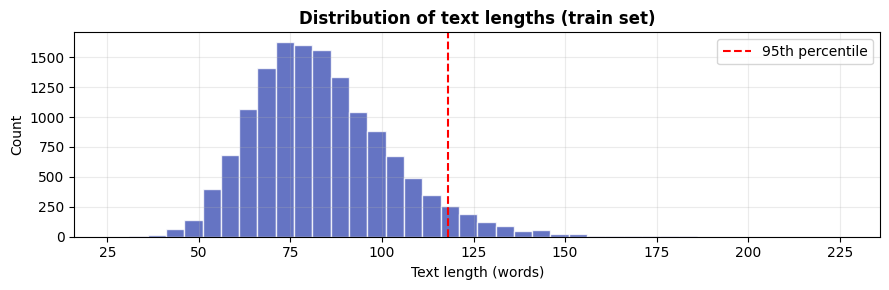

In [8]:
# Text length statistics
lengths = [len(t.split()) for t, _ in train_pairs]
print(f'Text length in words (train):')
print(f'  Min    : {min(lengths)}')
print(f'  Max    : {max(lengths)}')
print(f'  Mean   : {np.mean(lengths):.1f}')
print(f'  Median : {np.median(lengths):.1f}')
print(f'  95th % : {np.percentile(lengths, 95):.1f}')
print(f'\n  → Setting MAX_LEN=128 tokens (covers 95th percentile)')

# Word length histogram
fig, ax = plt.subplots(figsize=(9, 3))
ax.hist(lengths, bins=40, color='#3F51B5', alpha=0.8, edgecolor='white')
ax.axvline(np.percentile(lengths, 95), color='red', ls='--', lw=1.5, label='95th percentile')
ax.set_xlabel('Text length (words)'); ax.set_ylabel('Count')
ax.set_title('Distribution of text lengths (train set)', fontweight='bold')
ax.legend(); ax.grid(True, alpha=0.25)
plt.tight_layout()
plt.savefig('text_length_distribution.png', dpi=120, bbox_inches='tight')
plt.show()


## Section 3 — Tokenisation & PyTorch Dataset

In [9]:
# Load BERT tokenizer
# Using bert-base-uncased: 12 layers, 768 hidden, 110M params

BERT_MODEL = 'bert-base-uncased'
MAX_LEN    = 128  # covers 95th percentile of text lengths

print(f'Loading tokenizer: {BERT_MODEL}')
tokenizer = BertTokenizer.from_pretrained(BERT_MODEL)
print('Tokenizer loaded.')

# Verify on one example
sample_text = train_pairs[0][0]
enc = tokenizer(sample_text, max_length=MAX_LEN, truncation=True,
                padding='max_length', return_tensors='pt')
print(f'\nSample encoding:')
print(f'  input_ids shape    : {enc["input_ids"].shape}')
print(f'  attention_mask shape: {enc["attention_mask"].shape}')
print(f'  Decoded first 20 tokens: {tokenizer.convert_ids_to_tokens(enc["input_ids"][0][:20])}')

Loading tokenizer: bert-base-uncased


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Tokenizer loaded.

Sample encoding:
  input_ids shape    : torch.Size([1, 128])
  attention_mask shape: torch.Size([1, 128])
  Decoded first 20 tokens: ['[CLS]', 'later', 'that', 'evening', ',', 'tom', 'and', 'sara', 'sat', 'on', 'couch', 'in', 'the', 'living', 'room', '.', 'mike', ',', 'a', 'mutual']


In [10]:
# PyTorch Dataset class
class StoryTextDataset(Dataset):

    def __init__(self, pairs, tokenizer, max_len=128):
        self.pairs     = pairs
        self.tokenizer = tokenizer
        self.max_len   = max_len

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        text, label = self.pairs[idx]
        enc = self.tokenizer(
            text,
            max_length=self.max_len,
            truncation=True,
            padding='max_length',
            return_tensors='pt'
        )
        return {
            'input_ids':      enc['input_ids'].squeeze(0),
            'attention_mask': enc['attention_mask'].squeeze(0),
            'label':          torch.tensor(label, dtype=torch.long)
        }


# DataLoaders
BATCH_SIZE  = 32
NUM_WORKERS = 2

train_ds = StoryTextDataset(train_pairs, tokenizer, MAX_LEN)
val_ds   = StoryTextDataset(val_pairs,   tokenizer, MAX_LEN)
test_ds  = StoryTextDataset(test_pairs,  tokenizer, MAX_LEN)

train_dl = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                      num_workers=NUM_WORKERS, pin_memory=True)
val_dl   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                      num_workers=NUM_WORKERS, pin_memory=True)
test_dl  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False,
                      num_workers=NUM_WORKERS, pin_memory=True)

batch = next(iter(train_dl))
print(f'Train batches  : {len(train_dl)}')
print(f'Val   batches  : {len(val_dl)}')
print(f'Batch shapes   : input_ids={batch["input_ids"].shape}, '
      f'mask={batch["attention_mask"].shape}, labels={batch["label"].shape}')

Train batches  : 444
Val   batches  : 111
Batch shapes   : input_ids=torch.Size([32, 128]), mask=torch.Size([32, 128]), labels=torch.Size([32])



## Section 4 — Model Architectures

In [11]:
# EXPERIMENT 1 — Baseline BERT + Linear Classifier
class BertBaseline(nn.Module):

    def __init__(self, num_classes=5, model_name='bert-base-uncased'):
        super().__init__()
        self.bert       = BertModel.from_pretrained(model_name)
        hidden_size     = self.bert.config.hidden_size  # 768
        self.classifier = nn.Linear(hidden_size, num_classes)

    def forward(self, input_ids, attention_mask):
        outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        cls_emb = outputs.last_hidden_state[:, 0, :]  # [CLS] token: (B, 768)
        return self.classifier(cls_emb)               # (B, 5)


def count_params(m, trainable_only=True):
    if trainable_only:
        return sum(p.numel() for p in m.parameters() if p.requires_grad)
    return sum(p.numel() for p in m.parameters())


# Shape check
with torch.no_grad():
    m_test = BertBaseline()
    out    = m_test(batch['input_ids'], batch['attention_mask'])
print(f'BertBaseline output : {out.shape}  (expected [32, 5])')
print(f'Trainable params    : {count_params(m_test):,}')
del m_test

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


BertBaseline output : torch.Size([32, 5])  (expected [32, 5])
Trainable params    : 109,486,085


In [12]:
# EXPERIMENT 2 — BERT + Dropout
class BertWithDropout(nn.Module):

    def __init__(self, num_classes=5, model_name='bert-base-uncased', dropout=0.4):
        super().__init__()
        self.bert       = BertModel.from_pretrained(model_name)
        hidden_size     = self.bert.config.hidden_size
        self.dropout    = nn.Dropout(dropout)
        self.classifier = nn.Linear(hidden_size, num_classes)

    def forward(self, input_ids, attention_mask):
        outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        cls_emb = outputs.last_hidden_state[:, 0, :]
        return self.classifier(self.dropout(cls_emb))


with torch.no_grad():
    m = BertWithDropout()
print(f'BertWithDropout trainable params: {count_params(m):,}')
del m

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


BertWithDropout trainable params: 109,486,085


In [13]:
# EXPERIMENT 3 — BERT + Hidden Layer

class BertHiddenLayer(nn.Module):
    """BERT + two-layer classifier: Linear(768→256) → ReLU → Dropout → Linear(256→5)."""
    def __init__(self, num_classes=5, model_name='bert-base-uncased',
                 hidden=256, dropout=0.3):
        super().__init__()
        self.bert       = BertModel.from_pretrained(model_name)
        hidden_size     = self.bert.config.hidden_size
        self.classifier = nn.Sequential(
            nn.Linear(hidden_size, hidden),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, num_classes)
        )

    def forward(self, input_ids, attention_mask):
        outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        cls_emb = outputs.last_hidden_state[:, 0, :]
        return self.classifier(cls_emb)


with torch.no_grad():
    m = BertHiddenLayer()
print(f'BertHiddenLayer trainable params: {count_params(m):,}')
del m

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


BertHiddenLayer trainable params: 109,680,389


In [14]:
# EXPERIMENT 4 — BERT Frozen Backbone (Feature Extraction)

class BertFrozen(nn.Module):

    def __init__(self, num_classes=5, model_name='bert-base-uncased', dropout=0.3):
        super().__init__()
        self.bert = BertModel.from_pretrained(model_name)
        # Freeze ALL BERT parameters
        for param in self.bert.parameters():
            param.requires_grad = False
        hidden_size     = self.bert.config.hidden_size
        self.classifier = nn.Sequential(
            nn.Linear(hidden_size, 256),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(256, num_classes)
        )

    def forward(self, input_ids, attention_mask):
        with torch.no_grad():
            outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        cls_emb = outputs.last_hidden_state[:, 0, :]
        return self.classifier(cls_emb)


with torch.no_grad():
    m = BertFrozen()
print(f'BertFrozen total params     : {count_params(m, trainable_only=False):,}')
print(f'BertFrozen TRAINABLE params : {count_params(m, trainable_only=True):,}')
del m

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


BertFrozen total params     : 109,680,389
BertFrozen TRAINABLE params : 198,149


In [15]:
# EXPERIMENT 5 — BERT + Diffusion-Inspired Decoder Head

class SinusoidalEmbedding(nn.Module):
    """Sinusoidal timestep embedding from DDPM (Ho et al., 2020)."""
    def __init__(self, dim=64):
        super().__init__()
        self.dim = dim

    def forward(self, t):
        # t: LongTensor (B,) → FloatTensor (B, dim)
        half  = self.dim // 2
        freqs = torch.exp(
            -torch.log(torch.tensor(10000.0)) *
            torch.arange(half, device=t.device) / half
        )
        args = t.float()[:, None] * freqs[None]         # (B, half)
        return torch.cat([args.sin(), args.cos()], dim=-1)  # (B, dim)


class DiffusionRefinementBlock(nn.Module):

    def __init__(self, feat_dim=768, time_dim=64):
        super().__init__()
        self.time_proj = nn.Linear(time_dim, feat_dim)
        self.net = nn.Sequential(
            nn.Linear(feat_dim, feat_dim * 2),
            nn.GELU(),
            nn.Linear(feat_dim * 2, feat_dim),
        )
        self.norm = nn.LayerNorm(feat_dim)

    def forward(self, h, t_emb):
        # h: (B, feat_dim), t_emb: (B, time_dim)
        conditioned = h + self.time_proj(t_emb)     # timestep conditioning
        return self.norm(h + self.net(conditioned))  # residual refinement


class BertDiffusionDecoder(nn.Module):

    def __init__(self, num_classes=5, model_name='bert-base-uncased',
                 feat_dim=256, time_dim=64, T=3, dropout=0.2):
        super().__init__()
        self.T = T
        self.bert = BertModel.from_pretrained(model_name)
        bert_hidden = self.bert.config.hidden_size  # 768

        # Project BERT [CLS] → feat_dim
        self.proj = nn.Sequential(
            nn.Linear(bert_hidden, feat_dim),
            nn.LayerNorm(feat_dim),
            nn.GELU()
        )

        # Sinusoidal timestep embedding
        self.t_embed = SinusoidalEmbedding(time_dim)
        self.t_mlp   = nn.Sequential(
            nn.Linear(time_dim, time_dim * 2), nn.GELU(),
            nn.Linear(time_dim * 2, time_dim)
        )

        # T iterative refinement blocks
        self.diff_blocks = nn.ModuleList([
            DiffusionRefinementBlock(feat_dim, time_dim) for _ in range(T)
        ])

        # Final classifier
        self.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(feat_dim, feat_dim // 2),
            nn.GELU(),
            nn.Linear(feat_dim // 2, num_classes)
        )

    def forward(self, input_ids, attention_mask):
        B = input_ids.size(0)

        # 1. BERT encoding → [CLS] embedding
        bert_out = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        cls_emb  = bert_out.last_hidden_state[:, 0, :]  # (B, 768)

        # 2. Project to feat_dim
        h = self.proj(cls_emb)   # (B, feat_dim)

        # 3. Iterative diffusion refinement (T steps)
        for step, block in enumerate(self.diff_blocks):
            t     = torch.full((B,), step, dtype=torch.long, device=input_ids.device)
            t_emb = self.t_mlp(self.t_embed(t))   # (B, time_dim)
            h     = block(h, t_emb)               # (B, feat_dim)

        # 4. Classify
        return self.classifier(h)   # (B, 5)


# Shape check
with torch.no_grad():
    m = BertDiffusionDecoder()
    out = m(batch['input_ids'], batch['attention_mask'])
print(f'BertDiffusionDecoder output : {out.shape}  (expected [32, 5])')
print(f'Trainable params            : {count_params(m):,}')
del m

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


BertDiffusionDecoder output : torch.Size([32, 5])  (expected [32, 5])
Trainable params            : 110,569,925



## Section 5 — Training Engine

In [16]:
def run_epoch(model, loader, criterion, optimizer=None, scheduler=None, device=DEVICE):

    training = optimizer is not None
    model.train() if training else model.eval()
    total_loss = correct = total = 0

    ctx = torch.enable_grad() if training else torch.no_grad()
    with ctx:
        for batch in loader:
            ids  = batch['input_ids'].to(device,      non_blocking=True)
            mask = batch['attention_mask'].to(device,  non_blocking=True)
            lbls = batch['label'].to(device,           non_blocking=True)

            logits = model(ids, mask)
            loss   = criterion(logits, lbls)

            if training:
                optimizer.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()
                if scheduler:
                    scheduler.step()

            total_loss += loss.item() * ids.size(0)
            correct    += (logits.argmax(1) == lbls).sum().item()
            total      += ids.size(0)

    return total_loss / total, correct / total


def train_model(
    model, train_dl, val_dl,
    epochs=5, lr=2e-5, wd=0.01,
    warmup_ratio=0.1, patience=3,
    device=DEVICE, name='experiment'
):
    model     = model.to(device)
    criterion = nn.CrossEntropyLoss()

    # Standard BERT fine-tuning: no decay on bias/LayerNorm
    no_decay  = ['bias', 'LayerNorm.weight']
    optim_groups = [
        {'params': [p for n, p in model.named_parameters()
                    if not any(nd in n for nd in no_decay) and p.requires_grad],
         'weight_decay': wd},
        {'params': [p for n, p in model.named_parameters()
                    if any(nd in n for nd in no_decay) and p.requires_grad],
         'weight_decay': 0.0},
    ]
    optimizer = optim.AdamW(optim_groups, lr=lr)

    total_steps  = len(train_dl) * epochs
    warmup_steps = int(total_steps * warmup_ratio)
    scheduler    = get_linear_schedule_with_warmup(
        optimizer, num_warmup_steps=warmup_steps,
        num_training_steps=total_steps
    )

    hist = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    best_val_acc  = 0.0
    best_val_loss = float('inf')
    best_state    = None
    patience_ctr  = 0

    print(f'\n{"="*72}')
    print(f'  {name}')
    print(f'  LR={lr}  WD={wd}  Epochs={epochs}  Warmup={warmup_steps} steps')
    print(f'{"="*72}')
    print(f'{"Ep":<5}{"Tr Loss":<12}{"Tr Acc":<12}{"Va Loss":<12}{"Va Acc":<12}')
    print(f'{"-"*52}')

    for ep in range(1, epochs + 1):
        tr_loss, tr_acc = run_epoch(model, train_dl, criterion, optimizer, scheduler, device)
        va_loss, va_acc = run_epoch(model, val_dl,   criterion, None,      None,      device)

        hist['train_loss'].append(tr_loss)
        hist['val_loss'].append(va_loss)
        hist['train_acc'].append(tr_acc)
        hist['val_acc'].append(va_acc)

        marker = ' ★' if va_acc > best_val_acc else ''
        print(f'{ep:<5}{tr_loss:<12.4f}{tr_acc*100:<12.2f}{va_loss:<12.4f}{va_acc*100:<12.2f}{marker}')

        if va_acc > best_val_acc:
            best_val_acc  = va_acc
            best_val_loss = va_loss
            best_state    = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            patience_ctr  = 0
        else:
            patience_ctr += 1
            if patience_ctr >= patience:
                print(f'  Early stopping at epoch {ep}')
                break

    model.load_state_dict(best_state)
    final_tr_loss, final_tr_acc = run_epoch(model, train_dl, criterion, None, None, device)

    print(f'{"-"*52}')
    print(f'  Best val acc   : {best_val_acc*100:.2f}%')
    print(f'  Final train acc: {final_tr_acc*100:.2f}%')

    return {
        'history':          hist,
        'best_val_acc':     best_val_acc,
        'best_val_loss':    best_val_loss,
        'final_train_acc':  final_tr_acc,
        'final_train_loss': final_tr_loss,
        'model':            model,
    }

print('Training engine ready.')

Training engine ready.


## Section 6 — Five Experiments

In [17]:
EPOCHS   = 5
LR       = 2e-5
WD       = 0.01
PATIENCE = 3

results = {}  # stores all experiment outputs

In [18]:
# EXPERIMENT 1: Baseline BERT
results['BERT Baseline'] = train_model(
    BertBaseline(), train_dl, val_dl,
    epochs=EPOCHS, lr=LR, wd=WD, patience=PATIENCE,
    name='Exp 1 — BERT Baseline ([CLS] → Linear(768→5))'
)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



  Exp 1 — BERT Baseline ([CLS] → Linear(768→5))
  LR=2e-05  WD=0.01  Epochs=5  Warmup=222 steps
Ep   Tr Loss     Tr Acc      Va Loss     Va Acc      
----------------------------------------------------
1    1.2816      41.61       1.0489      52.82        ★
2    1.0079      54.64       1.0367      52.20       
3    0.8738      61.30       1.0456      53.07        ★
4    0.7593      67.45       1.1350      51.83       
5    0.6659      72.60       1.1452      52.59       
----------------------------------------------------
  Best val acc   : 53.07%
  Final train acc: 69.05%


In [19]:
# EXPERIMENT 2: BERT + Dropout
results['BERT + Dropout'] = train_model(
    BertWithDropout(dropout=0.4), train_dl, val_dl,
    epochs=EPOCHS, lr=LR, wd=WD, patience=PATIENCE,
    name='Exp 2 — BERT + Dropout(0.4) before classifier'
)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



  Exp 2 — BERT + Dropout(0.4) before classifier
  LR=2e-05  WD=0.01  Epochs=5  Warmup=222 steps
Ep   Tr Loss     Tr Acc      Va Loss     Va Acc      
----------------------------------------------------
1    1.3346      38.38       1.0590      52.25        ★
2    1.0271      53.74       1.0153      53.07        ★
3    0.9005      60.04       1.0759      52.71       
4    0.7899      65.04       1.0906      53.92        ★
5    0.6984      69.97       1.2176      51.07       
----------------------------------------------------
  Best val acc   : 53.92%
  Final train acc: 71.58%


In [20]:
# EXPERIMENT 3: BERT + Hidden Layer
results['BERT + Hidden Layer'] = train_model(
    BertHiddenLayer(hidden=256, dropout=0.3), train_dl, val_dl,
    epochs=EPOCHS, lr=LR, wd=WD, patience=PATIENCE,
    name='Exp 3 — BERT + 2-layer head (768→256→5)'
)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



  Exp 3 — BERT + 2-layer head (768→256→5)
  LR=2e-05  WD=0.01  Epochs=5  Warmup=222 steps
Ep   Tr Loss     Tr Acc      Va Loss     Va Acc      
----------------------------------------------------
1    1.3290      40.41       1.0758      51.92        ★
2    1.0428      53.16       1.0331      53.64        ★
3    0.9243      58.86       1.0311      54.37        ★
4    0.8191      64.92       1.1401      51.80       
5    0.7436      68.48       1.1519      51.61       
----------------------------------------------------
  Best val acc   : 54.37%
  Final train acc: 65.97%


In [21]:
# EXPERIMENT 4: BERT Frozen (feature extraction)
results['BERT Frozen'] = train_model(
    BertFrozen(dropout=0.3), train_dl, val_dl,
    epochs=EPOCHS, lr=1e-3,
    wd=WD, patience=PATIENCE,
    name='Exp 4 — BERT Frozen backbone (head only trained, LR=1e-3)'
)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



  Exp 4 — BERT Frozen backbone (head only trained, LR=1e-3)
  LR=0.001  WD=0.01  Epochs=5  Warmup=222 steps
Ep   Tr Loss     Tr Acc      Va Loss     Va Acc      
----------------------------------------------------
1    1.4825      32.25       1.3566      38.11        ★
2    1.3770      37.77       1.2917      42.36        ★
3    1.3473      39.81       1.2810      41.63       
4    1.3234      40.73       1.2681      42.02       
5    1.3180      41.21       1.2725      42.14       
  Early stopping at epoch 5
----------------------------------------------------
  Best val acc   : 42.36%
  Final train acc: 41.82%


In [22]:
# EXPERIMENT 5: BERT + Diffusion Decoder
results['BERT + Diffusion Decoder'] = train_model(
    BertDiffusionDecoder(feat_dim=256, time_dim=64, T=3, dropout=0.2),
    train_dl, val_dl,
    epochs=EPOCHS, lr=2e-5, wd=WD, patience=PATIENCE,
    name='Exp 5 — BERT + Diffusion Decoder Head (T=3 refinement steps)'
)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



  Exp 5 — BERT + Diffusion Decoder Head (T=3 refinement steps)
  LR=2e-05  WD=0.01  Epochs=5  Warmup=222 steps
Ep   Tr Loss     Tr Acc      Va Loss     Va Acc      
----------------------------------------------------
1    1.3043      40.40       1.1242      49.97        ★
2    1.0363      53.95       1.1348      51.01        ★
3    0.9177      59.35       1.1213      51.10        ★
4    0.8213      64.56       1.0598      53.92        ★
5    0.7322      68.91       1.1278      52.31       
----------------------------------------------------
  Best val acc   : 53.92%
  Final train acc: 70.72%



## Section 7 — Loss Curves & Accuracy Plots (20%)

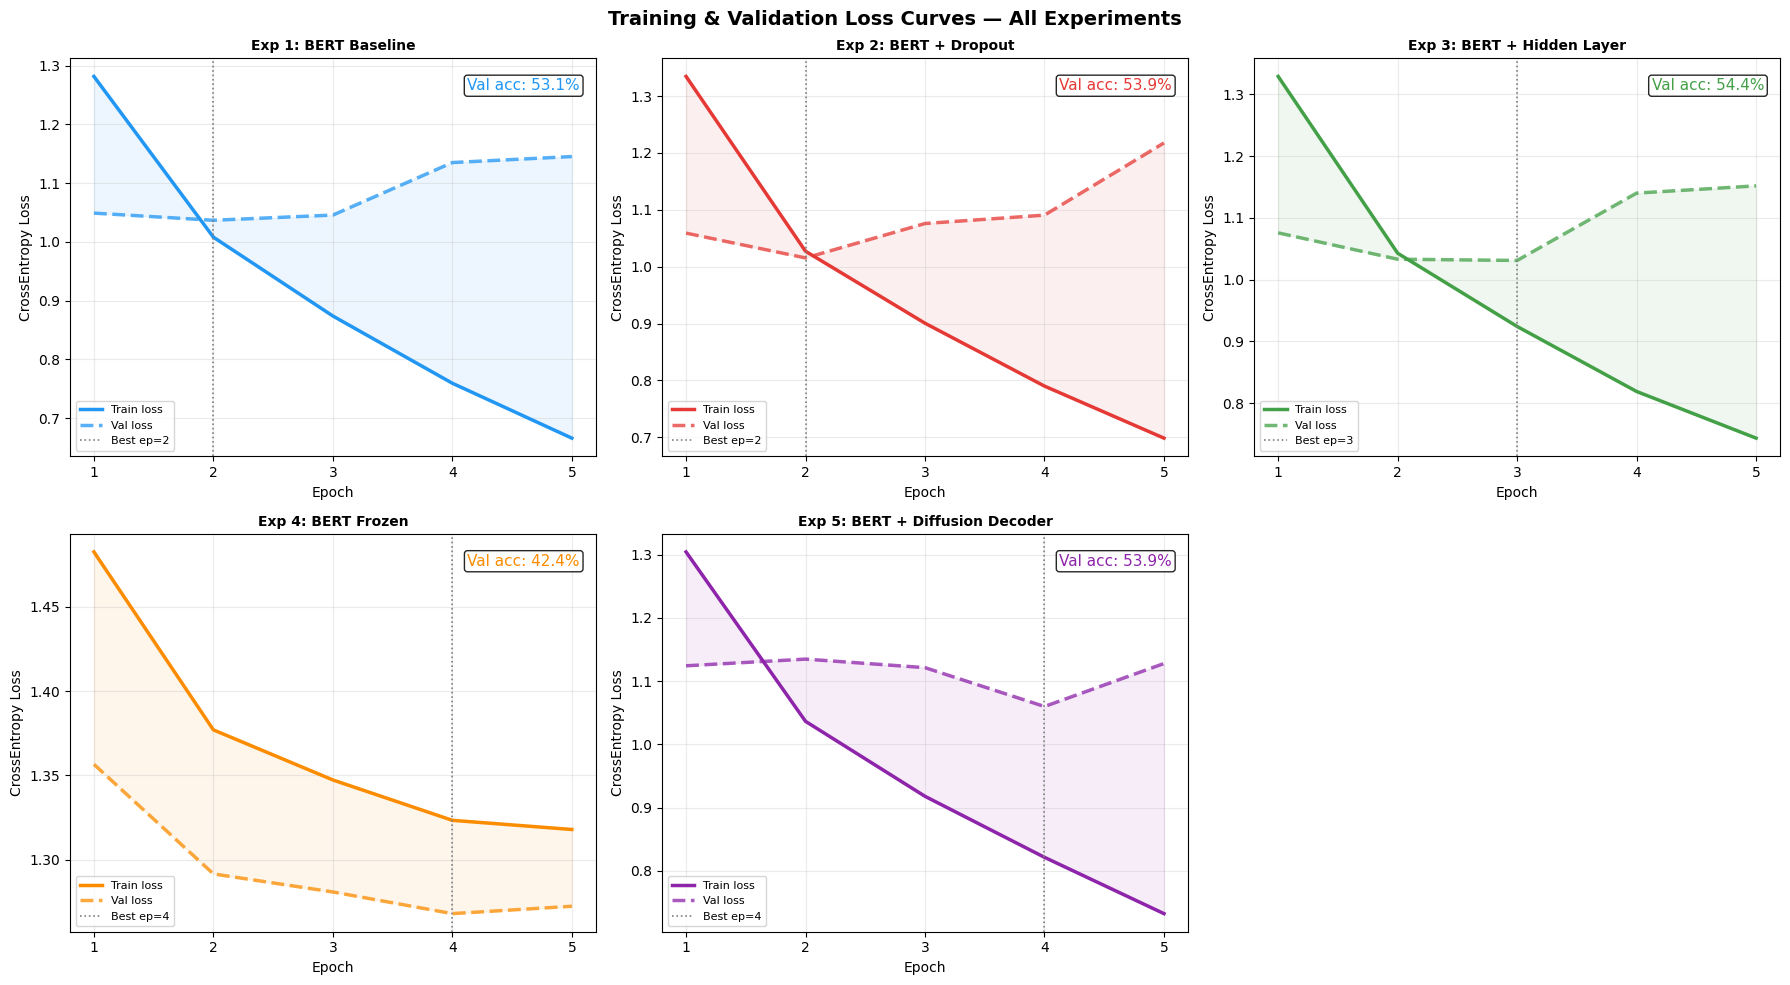

loss_curves.png saved.


In [23]:
COLOURS = ['#2196F3', '#E53935', '#43A047', '#FB8C00', '#8E24AA']

# Individual loss curves — one per experiment
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, (name, res) in enumerate(results.items()):
    ax = axes[i]
    h  = res['history']
    ep = range(1, len(h['train_loss']) + 1)
    c  = COLOURS[i]

    ax.plot(ep, h['train_loss'], color=c, lw=2.5, label='Train loss')
    ax.plot(ep, h['val_loss'],   color=c, lw=2.5, label='Val loss',
            linestyle='--', alpha=0.75)
    ax.fill_between(ep, h['train_loss'], h['val_loss'], color=c, alpha=0.08)

    best_ep = h['val_loss'].index(min(h['val_loss'])) + 1
    ax.axvline(best_ep, color='gray', ls=':', lw=1.2, label=f'Best ep={best_ep}')

    va = res['best_val_acc'] * 100
    ax.text(0.97, 0.95, f'Val acc: {va:.1f}%',
            transform=ax.transAxes, ha='right', va='top', fontsize=11,
            color=c, bbox=dict(fc='white', alpha=0.85, boxstyle='round,pad=0.2'))

    ax.set_title(f'Exp {i+1}: {name}', fontweight='bold', fontsize=10)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('CrossEntropy Loss')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.25)
    ax.set_xticks(list(ep))

axes[-1].set_visible(False)
fig.suptitle('Training & Validation Loss Curves — All Experiments',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('loss_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('loss_curves.png saved.')

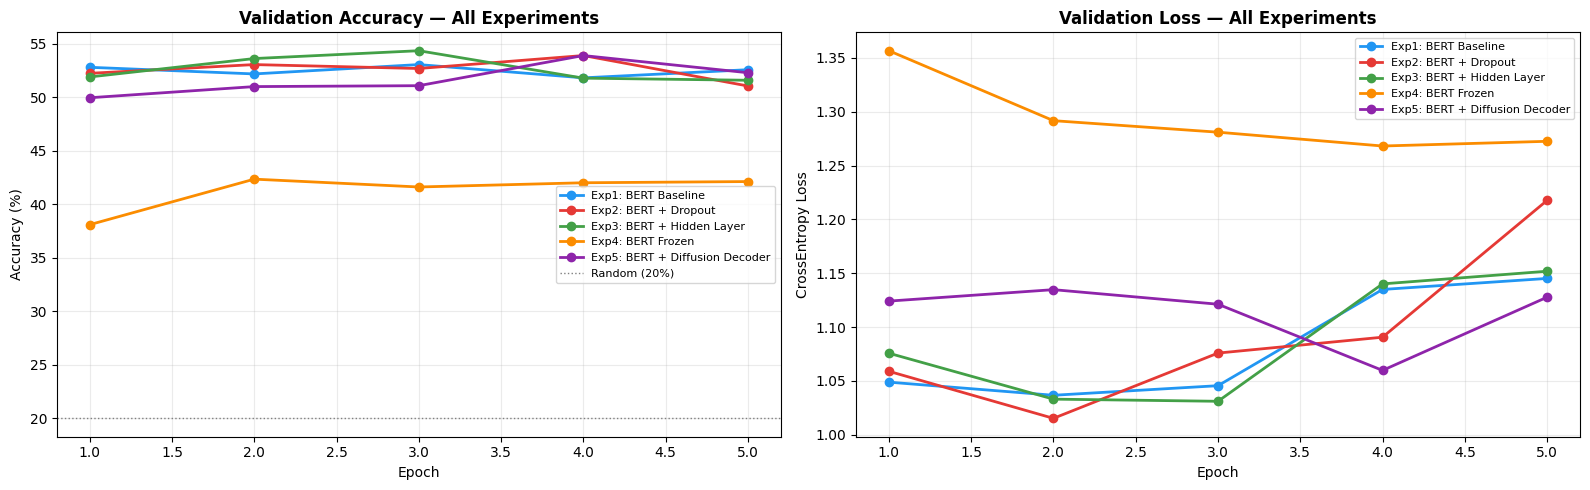

In [24]:
# Overlaid validation accuracy + loss
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

for i, (name, res) in enumerate(results.items()):
    h  = res['history']
    ep = range(1, len(h['val_acc']) + 1)
    ax1.plot(ep, [a*100 for a in h['val_acc']], color=COLOURS[i], lw=2,
             marker='o', label=f'Exp{i+1}: {name}')
    ax2.plot(ep, h['val_loss'],                 color=COLOURS[i], lw=2,
             marker='o', label=f'Exp{i+1}: {name}')

ax1.axhline(20, color='gray', ls=':', lw=1, label='Random (20%)')
ax1.set_title('Validation Accuracy — All Experiments', fontweight='bold')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Accuracy (%)')
ax1.legend(fontsize=8); ax1.grid(True, alpha=0.25)

ax2.set_title('Validation Loss — All Experiments', fontweight='bold')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('CrossEntropy Loss')
ax2.legend(fontsize=8); ax2.grid(True, alpha=0.25)

plt.tight_layout()
plt.savefig('val_curves_all.png', dpi=150, bbox_inches='tight')
plt.show()

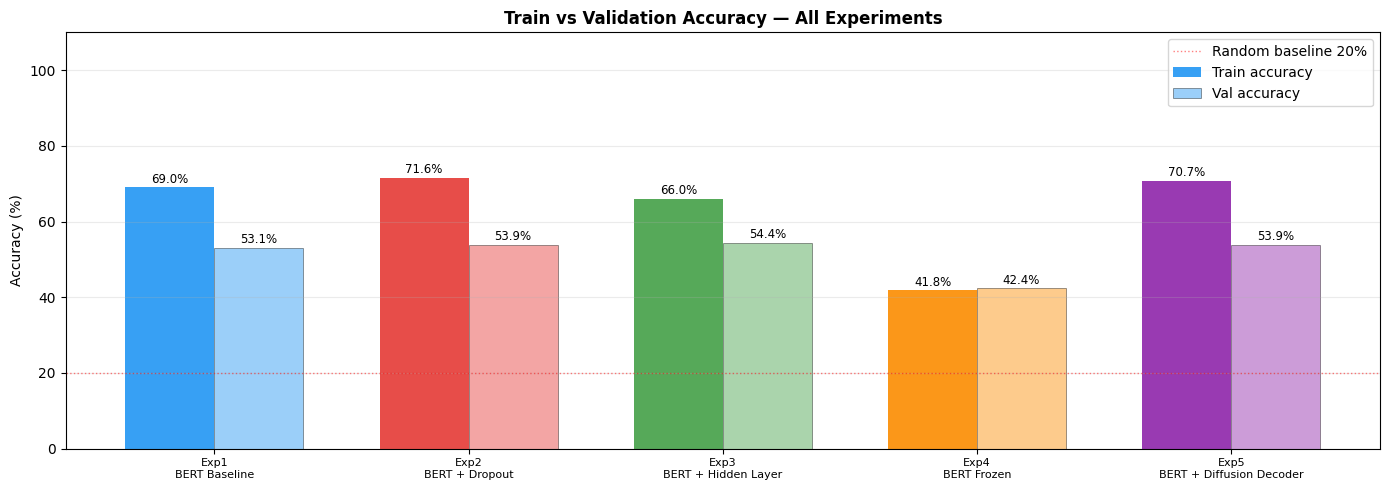

In [25]:
# Accuracy bar comparison
names   = list(results.keys())
tr_accs = [results[n]['final_train_acc'] * 100 for n in names]
va_accs = [results[n]['best_val_acc']    * 100 for n in names]
x       = np.arange(len(names))
w       = 0.35

fig, ax = plt.subplots(figsize=(14, 5))
b1 = ax.bar(x - w/2, tr_accs, w, color=COLOURS, alpha=0.9,  label='Train accuracy')
b2 = ax.bar(x + w/2, va_accs, w, color=COLOURS, alpha=0.45,
            edgecolor='black', linewidth=0.6, label='Val accuracy')

for bar, v in [(b, v) for bars, vs in [(b1, tr_accs), (b2, va_accs)]
               for b, v in zip(bars, vs)]:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.4,
            f'{v:.1f}%', ha='center', va='bottom', fontsize=8.5)

ax.axhline(20, color='red', ls=':', lw=1, alpha=0.5, label='Random baseline 20%')
ax.set_xticks(x)
ax.set_xticklabels([f'Exp{i+1}\n{n}' for i, n in enumerate(names)], fontsize=8)
ax.set_ylabel('Accuracy (%)'); ax.set_ylim(0, 110)
ax.set_title('Train vs Validation Accuracy — All Experiments', fontweight='bold')
ax.legend(); ax.grid(True, axis='y', alpha=0.25)
plt.tight_layout()
plt.savefig('accuracy_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


## Section 8 — Results Table

In [35]:
modifications = [
    'Baseline: [CLS] → Linear(768→5)',
    'Added Dropout(0.4) before classifier',
    'Two-layer head: 768→256→5 with ReLU',
    'Frozen BERT backbone; head-only training',
    'Novel diffusion-inspired decoder (T=3 steps)'
]

rows = []
for i, (name, res) in enumerate(results.items()):
    rows.append({
        'Experiment':    f'Exp {i+1}',
        'Name':          name,
        'Modification':  modifications[i],
        'Train Loss':    round(res['final_train_loss'], 4),
        'Val Loss':      round(res['best_val_loss'],    4),
        'Train Acc (%)': round(res['final_train_acc'] * 100, 2),
        'Val Acc (%)':   round(res['best_val_acc']    * 100, 2),
    })

df = pd.DataFrame(rows)
print('\n' + '='*95)
print('RESULTS TABLE ')
print('='*95)
print(df.to_string(index=False))
print('='*95)

df.to_csv('results_table.csv', index=False)
print('\nSaved: results_table.csv')


RESULTS TABLE 
Experiment                     Name                                 Modification  Train Loss  Val Loss  Train Acc (%)  Val Acc (%)
     Exp 1            BERT Baseline              Baseline: [CLS] → Linear(768→5)      0.7395    1.0456          69.05        53.07
     Exp 2           BERT + Dropout         Added Dropout(0.4) before classifier      0.6754    1.0906          71.58        53.92
     Exp 3      BERT + Hidden Layer          Two-layer head: 768→256→5 with ReLU      0.7963    1.0311          65.97        54.37
     Exp 4              BERT Frozen     Frozen BERT backbone; head-only training      1.2938    1.2917          41.82        42.36
     Exp 5 BERT + Diffusion Decoder Novel diffusion-inspired decoder (T=3 steps)      0.7167    1.0598          70.72        53.92

Saved: results_table.csv


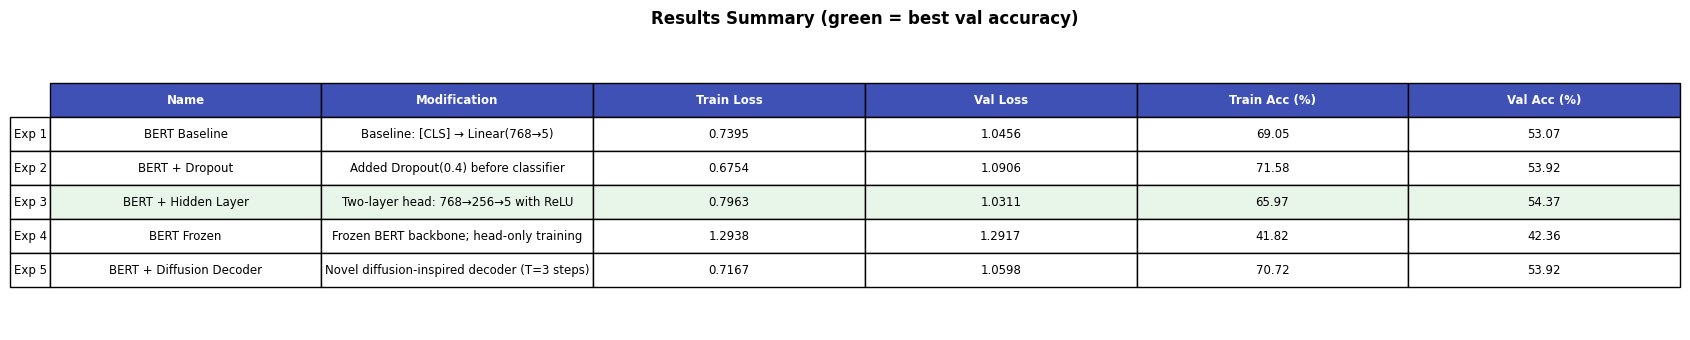

In [27]:
# Visual results table
fig, ax = plt.subplots(figsize=(17, 3.5))
ax.axis('off')
cols = ['Name', 'Modification', 'Train Loss', 'Val Loss', 'Train Acc (%)', 'Val Acc (%)']
data = [[r['Name'], r['Modification'], r['Train Loss'],
         r['Val Loss'], r['Train Acc (%)'], r['Val Acc (%)']] for r in rows]

tbl = ax.table(cellText=data, rowLabels=[r['Experiment'] for r in rows],
               colLabels=cols, cellLoc='center', loc='center')
tbl.auto_set_font_size(False); tbl.set_fontsize(8.5); tbl.scale(1, 1.9)

for j in range(len(cols)):
    tbl[0, j].set_facecolor('#3F51B5')
    tbl[0, j].set_text_props(color='white', fontweight='bold')

best_i = max(range(len(rows)), key=lambda k: rows[k]['Val Acc (%)'])
for j in range(len(cols)):
    tbl[best_i + 1, j].set_facecolor('#E8F5E9')

plt.title('Results Summary (green = best val accuracy)', fontweight='bold', pad=12)
plt.tight_layout()
plt.savefig('results_table.png', dpi=150, bbox_inches='tight')
plt.show()

## Section 9 — Detailed Evaluation of Best Model

In [28]:
# Best model
best_name  = max(results, key=lambda k: results[k]['best_val_acc'])
best_model = results[best_name]['model'].to(DEVICE)
print(f'Best model : {best_name}')
print(f'Val acc    : {results[best_name]["best_val_acc"]*100:.2f}%')

# Collect predictions
best_model.eval()
all_y, all_p = [], []
with torch.no_grad():
    for batch in val_dl:
        ids   = batch['input_ids'].to(DEVICE)
        mask  = batch['attention_mask'].to(DEVICE)
        preds = best_model(ids, mask).argmax(1).cpu().numpy()
        all_y.extend(batch['label'].numpy())
        all_p.extend(preds)

all_y = np.array(all_y); all_p = np.array(all_p)
CLASS_NAMES = [f'Position {i+1}' for i in range(5)]

print('\nClassification Report (Validation Set):')
print('='*60)
print(classification_report(all_y, all_p, target_names=CLASS_NAMES))

Best model : BERT + Hidden Layer
Val acc    : 54.37%

Classification Report (Validation Set):
              precision    recall  f1-score   support

  Position 1       0.92      0.93      0.92       710
  Position 2       0.60      0.55      0.57       709
  Position 3       0.34      0.28      0.31       710
  Position 4       0.35      0.39      0.37       710
  Position 5       0.51      0.58      0.54       709

    accuracy                           0.54      3548
   macro avg       0.54      0.54      0.54      3548
weighted avg       0.54      0.54      0.54      3548



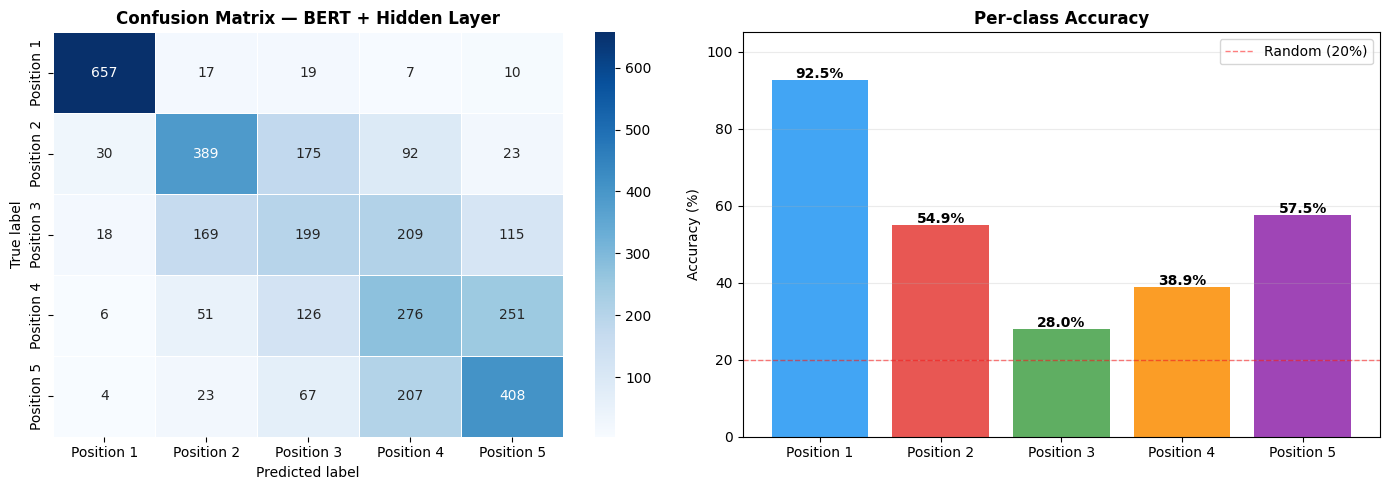

In [29]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Confusion matrix
cm = confusion_matrix(all_y, all_p)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
            linewidths=0.4, ax=ax1)
ax1.set_title(f'Confusion Matrix — {best_name}', fontweight='bold')
ax1.set_ylabel('True label'); ax1.set_xlabel('Predicted label')

# Per-class accuracy bar
per_class = cm.diagonal() / cm.sum(axis=1)
ax2.bar(CLASS_NAMES, per_class * 100, color=COLOURS[:5], alpha=0.85)
for j, v in enumerate(per_class):
    ax2.text(j, v*100 + 0.5, f'{v*100:.1f}%', ha='center',
             fontsize=10, fontweight='bold')
ax2.axhline(20, color='red', ls='--', lw=1, alpha=0.5, label='Random (20%)')
ax2.set_ylabel('Accuracy (%)'); ax2.set_ylim(0, 105)
ax2.set_title('Per-class Accuracy', fontweight='bold')
ax2.legend(); ax2.grid(True, axis='y', alpha=0.25)

plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()


## Section 10 — Save All Models

In [30]:
os.makedirs('saved_models', exist_ok=True)
fnames = ['exp1_bert_baseline', 'exp2_bert_dropout',
          'exp3_bert_hidden',   'exp4_bert_frozen',
          'exp5_bert_diffusion']

for fname, (name, res) in zip(fnames, results.items()):
    path = f'saved_models/{fname}.pth'
    torch.save(res['model'].state_dict(), path)
    print(f'Saved: {path}')

print('\nAll models saved.')

Saved: saved_models/exp1_bert_baseline.pth
Saved: saved_models/exp2_bert_dropout.pth
Saved: saved_models/exp3_bert_hidden.pth
Saved: saved_models/exp4_bert_frozen.pth
Saved: saved_models/exp5_bert_diffusion.pth

All models saved.
